In [1]:
# Get necessary packages

import yfinance as yf
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Calc sharpe ratio 
def sharpe_ratio(series, trading_days=252):
    mean = series.mean()
    std = series.std()
    return (mean / std) * np.sqrt(trading_days) if std > 0 else np.nan

In [3]:
# Get data
# We use SPY as our equity index and TLT as our bond index
tickers = ["SPY", "TLT"]

# Read in data from yFinance (TLT starts in 2002-07-30)
data = (
    yf.download(tickers, start="2002-07-30", end=None, auto_adjust=True)["Close"]
    .dropna()
)

# Convert to Polars
df = pl.from_pandas(data.reset_index())
df = df.rename({"Date": "date", "SPY": "SPY", "TLT": "TLT"}).sort("date")

# Compute daily returns
returns = df.with_columns([
    (pl.col("SPY") / pl.col("SPY").shift(1) - 1).alias("r_spy"),
    (pl.col("TLT") / pl.col("TLT").shift(1) - 1).alias("r_tlt"),
]).drop_nulls()

# Add year and month
returns = returns.with_columns([
    pl.col("date").dt.year().alias("year"),
    pl.col("date").dt.month().alias("month")
])

returns

[*********************100%***********************]  2 of 2 completed


date,SPY,TLT,r_spy,r_tlt,year,month
datetime[ns],f64,f64,f64,f64,i32,i8
2002-07-31 00:00:00,59.320873,37.379776,0.002418,0.01239,2002,7
2002-08-01 00:00:00,57.772152,37.592625,-0.026108,0.005694,2002,8
2002-08-02 00:00:00,56.47718,37.977592,-0.022415,0.010241,2002,8
2002-08-05 00:00:00,54.511982,38.14521,-0.034796,0.004414,2002,8
2002-08-06 00:00:00,56.34705,37.819084,0.033664,-0.00855,2002,8
…,…,…,…,…,…,…
2025-11-05 00:00:00,677.580017,88.959999,0.003465,-0.010896,2025,11
2025-11-06 00:00:00,670.309998,89.760002,-0.010729,0.008993,2025,11
2025-11-07 00:00:00,670.969971,89.57,0.000985,-0.002117,2025,11


In [4]:
# Compute signal and daily returns plot
paths = []
strategy_rows = []

for (yr, mo), g in returns.group_by(["year", "month"], maintain_order=True):
    g = g.sort("date")

    # Must have 15 days to determine signal
    if g.height < 15:
        continue

    # Assign loser/winner (or under/overperformer)
    spy_15 = g["r_spy"][:15].log1p().sum()
    tlt_15 = g["r_tlt"][:15].log1p().sum()

    if spy_15 > tlt_15:
        loser, winner = "r_tlt", "r_spy"
    else:
        loser, winner = "r_spy", "r_tlt"

    # Get daily returns for under/overperformer for that month AND next 5 days
    month_rets = g.select([
        "date",
        pl.col(loser).alias("ret_loser"),
        pl.col(winner).alias("ret_winner")
    ])

    # next month location
    if mo == 12:
        next_yr, next_mo = yr + 1, 1
    else:
        next_yr, next_mo = yr, mo + 1

    g_next = (
        returns
        .filter((pl.col("year") == next_yr) & (pl.col("month") == next_mo)))
    g_next = g_next.sort("date")

    # first 5 days of next month
    if g_next.height >= 5:
        next5 = g_next.slice(0, 5).select([
            "date",
            pl.col(loser).alias("ret_loser"),
            pl.col(winner).alias("ret_winner")
        ])
    else:
        next5 = None

    # combine month + next 5
    if next5 is not None:
        full = pl.concat([month_rets, next5])
    else:
        full = month_rets

    # Index path
    full = full.with_columns(pl.arange(1, full.height + 1).alias("t"))

    paths.append(full)

    # Build our signal (long last 7 trading days of underperformer and short first 3 days of the next month)
    # last 7 days long
    if g.height >= 7:
        buy7 = g.slice(g.height - 7).select([
            "date",
            pl.col(loser).alias("strat_ret")
        ])
        strategy_rows.append(buy7)

    # first 3 days next month short
    if g_next.height >= 3:
        short3 = g_next.slice(0, 3).select([
            "date",
            (-pl.col(loser)).alias("strat_ret")
        ])
        strategy_rows.append(short3)

In [5]:
# Get average returns across the months

all_paths = pl.concat(paths)

avg_path = (
    all_paths
    .group_by("t")
    .agg([
        pl.mean("ret_loser").alias("avg_ret_loser"),
        pl.mean("ret_winner").alias("avg_ret_winner"),
    ])
    .sort("t")
)

# cumulative log returns
avg_path = avg_path.with_columns([
    pl.col("avg_ret_loser").log1p().cum_sum().alias("cum_loser"),
    pl.col("avg_ret_winner").log1p().cum_sum().alias("cum_winner"),
])

In [6]:
# Calulcate signal returns
strategy = (
    pl.concat(strategy_rows)
    .sort("date")
    .with_columns(pl.col("strat_ret").log1p().cum_sum().alias("cum_strat"))
)

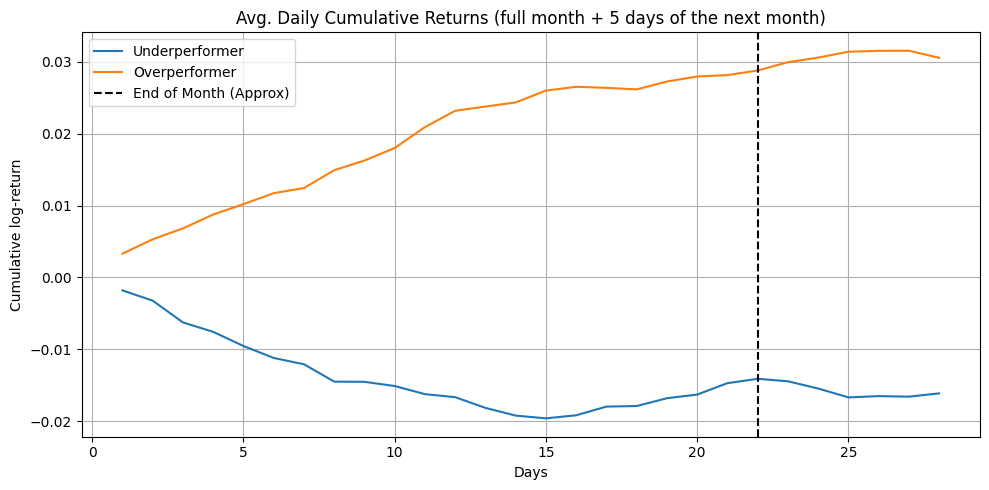

In [7]:
# Plot average daily returns path
plt.figure(figsize=(10,5))
plt.plot(avg_path["t"], avg_path["cum_loser"], label="Underperformer")
plt.plot(avg_path["t"], avg_path["cum_winner"], label="Overperformer")

plt.axvline(22, color="black", linestyle="--", label="End of Month (Approx)")
plt.title("Avg. Daily Cumulative Returns (full month + 5 days of the next month)")
plt.xlabel("Days")
plt.ylabel("Cumulative log-return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

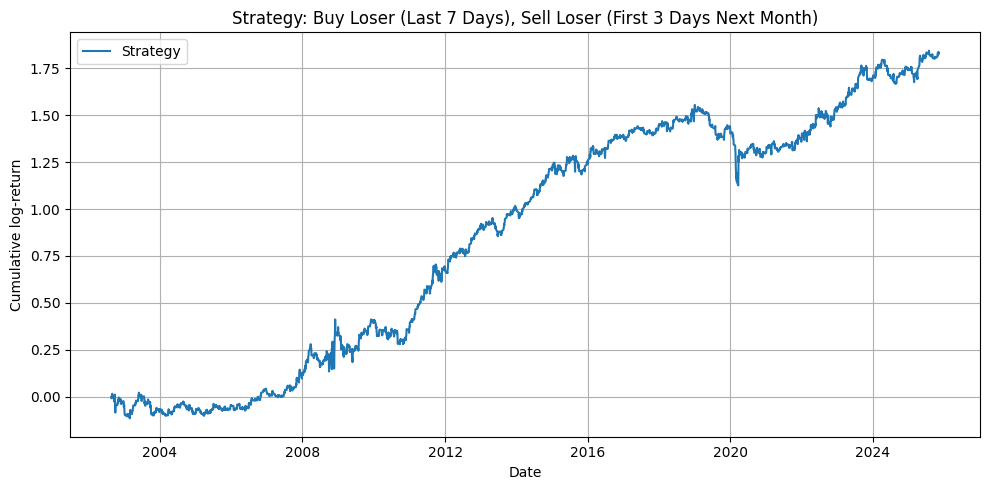

In [8]:
# Plot signal returns
plt.figure(figsize=(10,5))
plt.plot(strategy["date"], strategy["cum_strat"], label="Strategy")
plt.title("Strategy: Buy Loser (Last 7 Days), Sell Loser (First 3 Days Next Month)")
plt.xlabel("Date")
plt.ylabel("Cumulative log-return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Calculate signal sharpe
round(sharpe_ratio(strategy["strat_ret"].to_numpy()), 3)

np.float64(1.018)